# MNISym_coreg_regression pipeline

**Pipeline**: 

- run voxel-wise linear regression --> one intercept and one slope image per subject

- get the mean and median slope images for each of patients and controls

    - lesion is mirrored such that all lesions are on the right hemisphere with mean/median slope fcns

    - (note to self: perhaps we can take this out of the fcn loop and just use the flipped images?)

- flip lesions that are on LH to RH

- for these images (T1 anatomical; wm, gm, csf segmentations; logJac), get the volume in ROIs defined by the SUIT atlas as: mean, median, sum in a summarized dataframe


**Input**: images run through the pipeline "MNISym_coreg_normalize" - image for each subject-week (e.g. T1 anatomical normalized)

**Outputs**

* regression images (slope, intercept) - one per subject

* mean, median slope images for patients and controls

* flipped slope images (left lesion flipped) (where relevant)

* .tsv file


**Images that are currently used in this pipeline (each available for each subject-week)**

- normalized T1 anatomical

- normalized segmentations of: WM, GM, CSF

- log Jacobian determinant (transformation file)

In [ ]:
import numpy as np
import pandas as pd

import nibabel as nib

import smarts_cerebellum.globals as gl
from smarts_cerebellum.function_calls import flip_left_lesion, subj_unique_regression_week
from smarts_cerebellum import template_overall_image, make_summarized_dataframe

from pathlib import Path
import os

In [2]:
p_df = pd.read_csv(f'{gl.baseDir}/participants_anat.tsv', sep = '\t')

## regression

In [3]:
# run voxel-wise regression

# valid types for segment: T1, WM, GM, CSF, logJac
# make sure these have been normalized first.

In [4]:
def MNISym_regression(segment):
    """
    local function for running regression on files from pipeline MNISym_coreg_normalize

    segment (str): T1, WM, GM, CSF, logJac
    """

    subdir = f'MNISym_{segment}' # directory where each type of file is stored
    suffix = f'MNISym_{segment}_coreg_reslice'

    subj_unique_regression_week(subdir, suffix, p_df)

WHen running this for test, in smarts_cerebellum.util, temporary change resulkts_path to a different folder (just for testing)

In [ ]:
MNISym_regression('T1')
MNISym_regression('WM')
MNISym_regression('GM')
MNISym_regression('CSF')
MNISym_regression('logJac')

## mean/median images

Note that our present mean/median functions automatically flip all lesions to the right (i.e. automatically flip left lesions; right lesions + controls left alone)

For other parts (e.g. summarized dataframe), you will need to run flip_lesion part of this notebook!

(for now, possible improvements pending)

In [9]:
# needed for mean/median slope image calls

patients_df = p_df[p_df.isPatient == 1]
controls_df = p_df[p_df.isPatient == 0]

# download the template locally; change this path as needed
# change to web path
template_path = '/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/tpl-MNI152NLin2009cSymC_T1w.nii'

template_img = nib.load(template_path)
template_affine = template_img.affine

means_dir = f'{gl.baseDir}/Regression/mean_images'
medians_dir = f'{gl.baseDir}/Regression/median_images'

In [10]:
# get MEAN slope images
def MNISym_regression_mean(df, segment, 
                           group,
                           template_img = template_img, # use the template image defined above
                           template_affine = template_affine,
                           means_dir = means_dir
                           ):
    """
    local function for getting mean/median slope images

    segment (str): T1, WM, GM, CSF, logJac
    """
    suffix = f'MNISym_{segment}_coreg_reslice'

    # call
    mean_slope = template_overall_image.mean_image_right(df = df, suffix=suffix, template_img = template_img)

    # save image
    mean_slope_img = nib.Nifti1Image(mean_slope, template_affine)
    nib.save(mean_slope_img, f'{means_dir}/{group}_MNISym_{segment}_coreg_slope_mean.nii')

In [11]:
# get MEDIAN slope images
def MNISym_regression_median(df, segment, 
                           group,
                           template_img = template_img, # use the template image defined above
                           template_affine = template_affine,
                           means_dir = means_dir
                           ):
    """
    local function for running regression on files from pipeline MNISym_coreg_normalize

    segment (str): T1, WM, GM, CSF, logJac
    """

    suffix = f'MNISym_{segment}_coreg_reslice'

    # call
    median_slope = template_overall_image.median_image_right(df = df, suffix=suffix, template_img = template_img)

    # save image
    median_slope_img = nib.Nifti1Image(median_slope, template_affine)
    nib.save(median_slope_img, f'{means_dir}/{group}_MNISym_{segment}_coreg_slope_mean.nii')

In [ ]:
# get MEAN images for PATIENTS
MNISym_regression_mean(patients_df, 'T1','patients')
MNISym_regression_mean(patients_df, 'WM','patients')
MNISym_regression_mean(patients_df, 'GM','patients')
MNISym_regression_mean(patients_df, 'CSF','patients')
MNISym_regression_mean(patients_df, 'logJac','patients')

In [ ]:
# get MEDIAN images for PATIENTS
MNISym_regression_median(patients_df, 'T1','patients')
MNISym_regression_median(patients_df, 'WM','patients')
MNISym_regression_median(patients_df, 'GM','patients')
MNISym_regression_median(patients_df, 'CSF','patients')
MNISym_regression_median(patients_df, 'logJac','patients')

In [ ]:
# get MEAN images for CONTROLS
MNISym_regression_mean(controls_df, 'T1', 'controls')
MNISym_regression_mean(controls_df, 'WM', 'controls')
MNISym_regression_mean(controls_df, 'GM', 'controls')
MNISym_regression_mean(controls_df, 'CSF', 'controls')
MNISym_regression_mean(controls_df, 'logJac', 'controls')

In [ ]:
# get MEDIAN images for CONTROLS
MNISym_regression_median(controls_df, 'T1', 'controls')
MNISym_regression_median(controls_df, 'WM', 'controls')
MNISym_regression_median(controls_df, 'GM', 'controls')
MNISym_regression_median(controls_df, 'CSF', 'controls')
MNISym_regression_median(controls_df, 'logJac', 'controls')

## flip lesion

If you want to save flipped images; useful for making summarized df

In [13]:
# flip slope images for left_lesion patients

# same base path where all subject files are stored
#path = f'{gl.baseDir}/Regression'
# test
path = f'{gl.baseDir}/Regression'
left_lesion_df = p_df[p_df.LesionSide == 'left ']

def MNISym_lesion_flip(segment,
                           ):
    """
    local function for running flip slope

    segment (str): T1, WM, GM, CSF, logJac
    """
    suffix = f'MNISym_{segment}_coreg_reslice_slope'

    # call
    flip_left_lesion(path = path, left_lesion_df = left_lesion_df, suffix = suffix)

In [ ]:
MNISym_lesion_flip(segment = 'T1')
MNISym_lesion_flip(segment = 'GM')
MNISym_lesion_flip(segment = 'WM')
MNISym_lesion_flip(segment = 'CSF')
MNISym_lesion_flip(segment = 'logJac')

## make summarized df

In [5]:
# use flipped images where necessary
suffixes = [
    'MNISym_CSF_coreg_reslice_slope.nii.gz',
    'MNISym_logJac_coreg_reslice_slope.nii.gz',
    'MNISym_WM_coreg_reslice_slope.nii.gz',
    'MNISym_GM_coreg_reslice_slope.nii.gz',
    'MNISym_T1_coreg_reslice_slope.nii.gz'
]

flipped_suffixes = [
    'MNISym_CSF_coreg_reslice_slope_FlipLR.nii.gz',
    'MNISym_logJac_coreg_reslice_slope_FlipLR.nii.gz',
    'MNISym_WM_coreg_reslice_slope_FlipLR.nii.gz',
    'MNISym_GM_coreg_reslice_slope_FlipLR.nii.gz',
    'MNISym_T1_coreg_reslice_slope_FlipLR.nii.gz'
]

In [ ]:
search_path = os.path.join(gl.baseDir, 'Regression')

summarized_df = make_summarized_dataframe.make_summarized_dataframe(p_df = p_df,
                               search_path = search_path,
                               the_atlas = 'Diedrichsen_2009',
                               maps = 'atl-Anatom',
                               space = 'MNISym',
                               suffixes = suffixes,
                               flipped_suffixes = flipped_suffixes,
                               flip = 'left'
                               )
#summarized_df.to_csv(os.path.join(search_path, 'MNISym_coreg_slope_AtlasSUIT_summarized.tsv'), sep='\t', index=False)

# clean up

In [ ]:
search_path = os.path.join(gl.baseDir, 'Regression')

p_df = pd.read_csv('/cifs/diedrichsen/data/smarts_cerebellum/participants_anat.tsv', sep = '\t')

left_lesion_df = p_df[p_df.LesionSide == 'left ']

flip_left_lesion(search_path, left_lesion_df, segment='T1')
flip_left_lesion(search_path, left_lesion_df, segment='GM')
flip_left_lesion(search_path, left_lesion_df, segment='WM')
flip_left_lesion(search_path, left_lesion_df, segment='logJac')

Skip CU_2697
Skip JHU_2374
Skip CU_2697
Skip JHU_2374
Skip CU_2697
Skip JHU_2374
Skip CU_2697
Skip JHU_2374


In [ ]:
df = make_summarized_dataframe(p_df = p_df,
                               search_path = search_path,
                               the_atlas = 'Diedrichsen_2009',
                               maps = 'atl-Anatom',
                               space = 'MNISym')
df.to_csv(os.path.join(search_path, 'MNISym_coreg_slope_AtlasSUIT_summarized.tsv'), sep='\t', index=False)

Writing data for CU_2310


KeyError: 0

In [ ]:
df = pd.read_csv(os.path.join(search_path, 'MNISym_coreg_slope_AtlasSUIT_summarized.tsv'), sep='\t')

In [ ]:
rois = ['Left_I_IV', 'Right_I_IV', 'Left_V', 'Right_V', 'Left_VI', 'Right_VI']
df_rois_CSF = df[df.regionname.isin(rois) & (df.image==1)]
df_rois_GM = df[df.regionname.isin(rois) & (df.image==4)]
df_rois_WM = df[df.regionname.isin(rois) & (df.image==3)]
df_rois_T1 = df[df.regionname.isin(rois) & (df.image==5)]
df_rois_logJac = df[df.regionname.isin(rois) & (df.image==2)]

<Axes: xlabel='regionname', ylabel='median'>

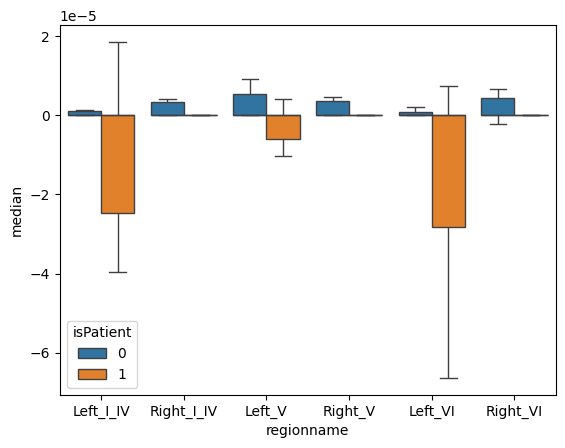

In [ ]:
sns.boxplot(data=df_rois_GM, x='regionname', y='median', hue='isPatient', showfliers=False )

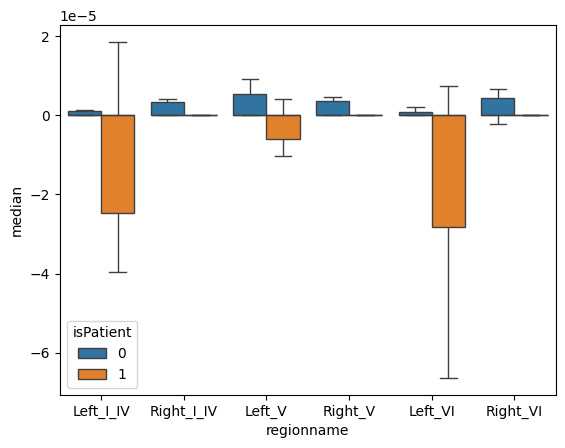

<Axes: xlabel='regionname', ylabel='median'>

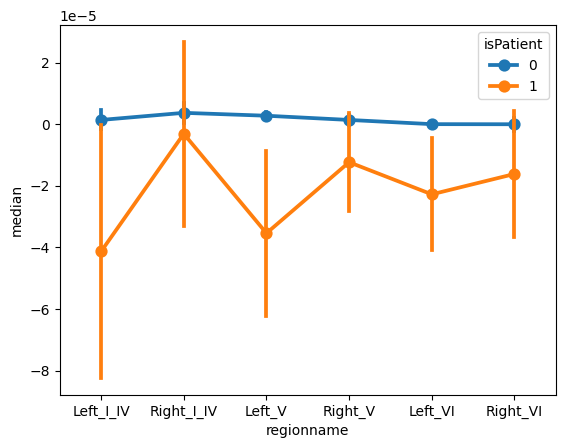

In [ ]:
sns.pointplot(data=df_rois_GM, x='regionname', y='median', hue='isPatient', errorbar='se')

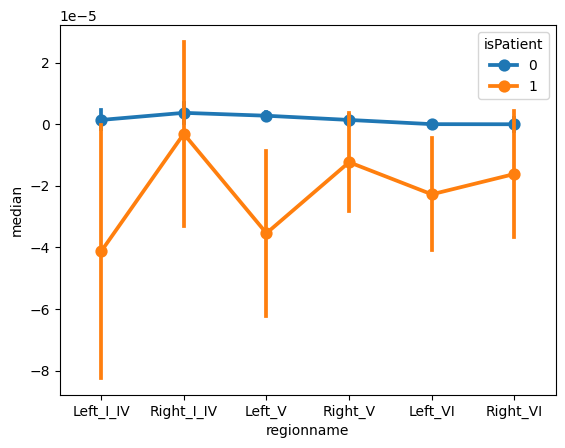